In [1]:
import numpy as np
import torch


class NACA_airfoil:
    def __init__(self):

        profils = ['2412', '6412']
        self.naca_profil = profils[np.random.randint(2)]

        scale_range = (0.5, 0.75)
        translation_range = (0.1, 0.15)
        self.m = int(self.naca_profil[0])/100
        self.p = int(self.naca_profil[1])/10
        self.t = int(self.naca_profil[2:])/100
        self.c = 1.0

        x = np.linspace(0, 1, 100)
        self.random_angle =  np.pi * np.random.rand() 

        self.suction_side, self.pressure_side = self.naca4(x)

        self.suction_side[-1, :] = self.pressure_side[-1, :]
        self.suction_side[0, :] = self.pressure_side[0, :]

        self.scale_factor = np.random.uniform(scale_range[0], scale_range[1])
        self.translate_factor = np.random.uniform(translation_range[0], translation_range[1])
        
        self.suction_side, self.pressure_side = self.scale(
            self.suction_side, self.pressure_side, self.scale_factor)

        self.suction_side_rotated, self.pressure_side_rotated = self.rotate()

    def camber_line(self, x):
        return np.where((x >= 0) & (x <= (self.c * self.p)),
                        self.m * (x / np.power(self.p, 2)) *
                        (2.0 * self.p - (x / self.c)),
                        self.m * ((self.c - x) / np.power(1 - self.p, 2)) * (1.0 + (x / self.c) - 2.0 * self.p))

    def dyc_over_dx(self, x):
        return np.where((x >= 0) & (x <= (self.c * self.p)),
                        ((2.0 * self.m) / np.power(self.p, 2)) *
                        (self.p - x / self.c),
                        ((2.0 * self.m) / np.power(1 - self.p, 2)) * (self.p - x / self.c))

    def thickness(self, x):
        term1 = 0.2969 * (np.sqrt(x/self.c))
        term2 = -0.1260 * (x/self.c)
        term3 = -0.3516 * np.power(x/self.c, 2)
        term4 = 0.2843 * np.power(x/self.c, 3)
        term5 = -0.1015 * np.power(x/self.c, 4)
        return 5 * self.t * self.c * (term1 + term2 + term3 + term4 + term5)

    def naca4(self, x):
        dyc_dx = self.dyc_over_dx(x)
        th = np.arctan(dyc_dx)
        yt = self.thickness(x)
        yc = self.camber_line(x)
        suction_side = np.array([x - yt*np.sin(th), yc + yt*np.cos(th)]).T
        pressure_side = np.array([x + yt*np.sin(th), yc - yt*np.cos(th)]).T

        # Add 0.5 to the y coordinate for normalization (current range y =[-0.5,0.5] transformation => y =[0,1])
        pressure_side[:, 1] = pressure_side[:, 1]+0.5
        suction_side[:, 1] = suction_side[:, 1]+0.5

        return suction_side, pressure_side

    def scale(self, suction_side, pressure_side, scale_factor):
        suction_side_scaled = suction_side * scale_factor + self.translate_factor
        pressure_side_scaled = pressure_side * scale_factor +self.translate_factor
        return suction_side_scaled, pressure_side_scaled

    def rotate(self):
        try:
            phi = self.random_angle
            rotation = np.array(
                [[np.cos(phi), -np.sin(phi)], [np.sin(phi), np.cos(phi)]])

            center = (np.mean(self.suction_side, axis=0) +
                      np.mean(self.pressure_side, axis=0)) / 2

            translation_to_origin = -center
            translation_back = center

            translated_suction_side = self.suction_side + translation_to_origin
            rotated_suction_side = np.dot(
                translated_suction_side, rotation) + translation_back

            translated_pressure_side = self.pressure_side + translation_to_origin
            rotated_pressure_side = np.dot(
                translated_pressure_side, rotation) + translation_back

            return rotated_suction_side, rotated_pressure_side
        except:
            print('Geometry not generated yet')

In [2]:
from os import write
import gmsh
import numpy as np
import torch
from torch_geometric.utils import to_undirected, remove_isolated_nodes
from torch_geometric.data import Data


airfoil = NACA_airfoil()

In [3]:
#  def face_to_edges(faces):
#         if faces.size()[0] == 3:
#             edges = torch.cat(
#                 [faces[[0, 1], :], faces[[1, 2], :], faces[[2, 0], :]], dim=1)
#         if faces.size()[0] == 4:
#             edges = torch.cat([faces[[0, 1], :], faces[[1, 2], :], faces[[
#                               2, 3], :], faces[[3, 0], :]], dim=1)

#         edges = to_undirected(edges)
#         edges = edges.to(torch.long)
#         return edges
    
# gmsh.initialize()
# gmsh.model.add("Airfoil Mesh")
# occ = gmsh.model.occ

# boundary_points = [
#     [0, 0, 0],
#     [1, 0, 0],
#     [1, 1, 0],
#     [0, 1, 0]
# ]
# boundary_tags = []
# for i, point in enumerate(boundary_points):
#     boundary_tags.append(occ.addPoint(*point, lc, tag=i + 1))
# boundary_lines = [
#     occ.addLine(boundary_tags[0], boundary_tags[1]),
#     occ.addLine(boundary_tags[1], boundary_tags[2]),
#     occ.addLine(boundary_tags[2], boundary_tags[3]),
#     occ.addLine(boundary_tags[3], boundary_tags[0])
# ]
# outer_loop = occ.addCurveLoop(boundary_lines)

# # Add airfoil geometry as a spline
# suction_points = []
# pressure_points = []
# for i, point in enumerate(airfoil.suction_side_rotated):
#     suction_points.append(occ.addPoint(point[0], point[1], 0, lc))
# for i, point in enumerate(airfoil.pressure_side_rotated):
#     pressure_points.append(occ.addPoint(point[0], point[1], 0, lc))

# suction_spline = occ.addSpline(suction_points)
# pressure_spline = occ.addSpline(pressure_points)
# airfoil_loop = occ.addCurveLoop([suction_spline, pressure_spline])

# # Add the plane surface
# plane_surface = occ.addPlaneSurface([outer_loop, airfoil_loop])
# occ.synchronize()

# # Generate the mesh
# gmsh.model.mesh.generate(2)

# node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
# node_coords = np.array(node_coords).reshape(-1, 3)
# node_coords_tensor = torch.from_numpy(node_coords).float()
# node_tags = node_tags - 1  # Convert to 0-based indexing

# element_types, element_tags, node_tags_per_element = gmsh.model.mesh.getElements()
# node_tags, node_coords, parametricCoord = gmsh.model.mesh.getNodes(returnParametricCoord=True)
# faces = None

# # Check for triangles and quads
# for etype, etags, ntags in zip(element_types, element_tags, node_tags_per_element):
#     if etype == 2:  # Triangles
#         faces = np.array(ntags).reshape(-1, 3) - \
#             1  # Convert to 0-based indexing
#         break
#     elif etype == 3:  # Quadrilaterals
#         faces = np.array(ntags).reshape(-1, 4) - \
#             1  # Convert to 0-based indexing

# if faces is None:
#     raise ValueError(
#         "No triangular or quadrilateral elements found in the mesh.")

# # Convert faces to PyTorch format
# faces_tensor = torch.tensor(faces.T.astype(
#     np.int64), dtype=torch.long)  # Transpose and cast to int64

# # Remove isolated nodes and adjust new node indices in faces_tensor
# edge_index = face_to_edges(faces_tensor)
# new_edge_index, _, mask = remove_isolated_nodes(edge_index)

# # Create a mapping for old to new indices
# index_mapping = torch.full(
#     (node_coords_tensor.size(0),), -1, dtype=torch.long)
# index_mapping[mask] = torch.arange(mask.sum(), dtype=torch.long)

# # Adjust faces to remove invalid faces and remap indices
# valid_faces_mask = (index_mapping[faces_tensor] >= 0).all(
#     dim=0)  # Check if all nodes in a face are valid
# # Keep only valid faces
# filtered_faces = faces_tensor[:, valid_faces_mask]
# # Remap old indices to new indices
# updated_faces = index_mapping[filtered_faces]
# normals = torch.zeros([node_coords_tensor.size(0),2],dtype = torch.float)
# # Process node dimensions if needed
# for i in range(node_coords_tensor.size(0)):
#     nodeTag = i + 1
#     coord, coord_param, dim, tag = gmsh.model.mesh.getNode(nodeTag)
#     node_coords_tensor[i, 2] = dim
#     normal = gmsh.model.get_normal(tag,coord_param)
#     normals[i,:] = torch.from_numpy(normal)


In [4]:
# for i in range(node_coords_tensor.size(0)):
#     nodeTag = i + 1
#     coord, coord_param, dim, tag = gmsh.model.mesh.getNode(nodeTag)
#     node_coords_tensor[i, 2] = dim
#     if dim == 2:
#         normal = gmsh.model.get_normal(tag,coord_param)
#         normals[i,:] = torch.from_numpy(normal)


In [35]:
from os import write
import gmsh
import numpy as np
import torch
from torch_geometric.utils import to_undirected, remove_isolated_nodes
from torch_geometric.data import Data


class MeshGenerator:
    def __init__(self, airfoil, lc=0.5, quadMesh=False):
        self.is_quad_mesh = quadMesh
        self.mesh = self.get_mesh_of_airfoil(lc, airfoil)
        self.mesh.nodes_faces_ids = self.map_nodes_to_faces()
        self.mesh.edge_attr = self.add_edge_attr()
        self.mesh.face_attr = self.add_face_attr()

        self.mesh = self.getFaceCenterPoints()
        self.normalize_mesh_coordinates()

    def get_mesh_of_airfoil(self, lc, airfoil):
        gmsh.initialize()
        gmsh.model.add("Airfoil Mesh")
        occ = gmsh.model.occ

        boundary_points = [
            [0, 0, 0],
            [1, 0, 0],
            [1, 1, 0],
            [0, 1, 0]
        ]
        boundary_tags = []
        for i, point in enumerate(boundary_points):
            boundary_tags.append(occ.addPoint(*point, lc, tag=i + 1))
        boundary_lines = [
            occ.addLine(boundary_tags[0], boundary_tags[1]),
            occ.addLine(boundary_tags[1], boundary_tags[2]),
            occ.addLine(boundary_tags[2], boundary_tags[3]),
            occ.addLine(boundary_tags[3], boundary_tags[0])
        ]
        outer_loop = occ.addCurveLoop(boundary_lines)

        # Add airfoil geometry as a spline
        suction_points = []
        pressure_points = []
        for i, point in enumerate(airfoil.suction_side_rotated):
            suction_points.append(occ.addPoint(point[0], point[1], 0, lc))
        for i, point in enumerate(airfoil.pressure_side_rotated):
            pressure_points.append(occ.addPoint(point[0], point[1], 0, lc))

        suction_spline = occ.addSpline(suction_points)
        pressure_spline = occ.addSpline(pressure_points)
        airfoil_loop = occ.addCurveLoop([suction_spline, pressure_spline])

        # Add the plane surface
        plane_surface = occ.addPlaneSurface([outer_loop, airfoil_loop])
        occ.synchronize()
        if self.is_quad_mesh == True:
            # Mesh settings
            gmsh.option.setNumber("Mesh.Algorithm", 11)  # MeshAdapt algorithm
            gmsh.option.setNumber("Mesh.RecombineAll", 1)
            gmsh.option.setNumber("Mesh.Smoothing", 10)  # Smoothing steps

        # Generate the mesh
        gmsh.model.mesh.generate(2)

        node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
        node_coords = np.array(node_coords).reshape(-1, 3)
        node_coords_tensor = torch.from_numpy(node_coords).float()
        node_tags = node_tags - 1  # Convert to 0-based indexing

        element_types, element_tags, node_tags_per_element = gmsh.model.mesh.getElements()

        faces = None

        # Check for triangles and quads
        for etype, etags, ntags in zip(element_types, element_tags, node_tags_per_element):
            if etype == 2:  # Triangles
                faces = np.array(ntags).reshape(-1, 3) - \
                    1  # Convert to 0-based indexing
                break
            elif etype == 3:  # Quadrilaterals
                faces = np.array(ntags).reshape(-1, 4) - \
                    1  # Convert to 0-based indexing

        if faces is None:
            raise ValueError(
                "No triangular or quadrilateral elements found in the mesh.")

        # Convert faces to PyTorch format
        faces_tensor = torch.tensor(faces.T.astype(
            np.int64), dtype=torch.long)  # Transpose and cast to int64

        # Remove isolated nodes and adjust new node indices in faces_tensor
        edge_index = self.face_to_edges(faces_tensor)
        new_edge_index, _, mask = remove_isolated_nodes(edge_index)

        # Create a mapping for old to new indices
        index_mapping = torch.full(
            (node_coords_tensor.size(0),), -1, dtype=torch.long)
        index_mapping[mask] = torch.arange(mask.sum(), dtype=torch.long)

        # Adjust faces to remove invalid faces and remap indices
        valid_faces_mask = (index_mapping[faces_tensor] >= 0).all(
            dim=0)  # Check if all nodes in a face are valid
        # Keep only valid faces
        filtered_faces = faces_tensor[:, valid_faces_mask]
        # Remap old indices to new indices
        updated_faces = index_mapping[filtered_faces]
       # Process node dimensions if needed
        for i in range(node_coords_tensor.size(0)):
            nodeTag = i + 1
            coord, _, dim, tag = gmsh.model.mesh.getNode(nodeTag)
            node_coords_tensor[i, 2] = dim
 
        # Update node coordinates based on mask
        new_node_coords = node_coords_tensor[mask, :]

        gmsh.finalize()

        mesh = Data(x=new_node_coords, edge_index=new_edge_index,
                    faces=updated_faces)

        return mesh

    def face_to_edges(self, faces):
        if faces.size()[0] == 3:
            edges = torch.cat(
                [faces[[0, 1], :], faces[[1, 2], :], faces[[2, 0], :]], dim=1)
        if faces.size()[0] == 4:
            edges = torch.cat([faces[[0, 1], :], faces[[1, 2], :], faces[[
                              2, 3], :], faces[[3, 0], :]], dim=1)

        edges = to_undirected(edges)
        edges = edges.to(torch.long)
        return edges

    def normalize_mesh_coordinates(self):
        nodeDim = self.mesh.x.size()[0]
        transformValues = torch.zeros(nodeDim, dtype=torch.float)

        xMin = (torch.min(self.mesh.x, dim=0)).values[0]
        xMax = (torch.max(self.mesh.x, dim=0)).values[0]
        yMin = (torch.min(self.mesh.x, dim=0)).values[1]
        yMax = (torch.max(self.mesh.x, dim=0)).values[1]

        transformValues[0] = xMin
        transformValues[1] = xMax
        transformValues[2] = yMin
        transformValues[3] = yMax

        normNodes = torch.zeros((nodeDim, 2), dtype=torch.float)
        normNodes[:, 0] = (self.mesh.x[:, 0]-xMin)/(xMax-xMin)
        normNodes[:, 1] = (self.mesh.x[:, 1]-yMin)/(yMax-yMin)

        # num_center_nodes = self.mesh.centerPoints.size()[0]
        # normCenterNodes = torch.zeros((num_center_nodes, 2), dtype=torch.float)
        # normCenterNodes[:, 0] = (self.mesh.centerPoints[:, 0]-xMin)/(xMax-xMin)
        # normCenterNodes[:, 1] = (self.mesh.centerPoints[:, 1]-yMin)/(yMax-yMin)
        # self.mesh.centerPoints = normCenterNodes
        self.mesh.x[:, 0:2] = normNodes

    def map_nodes_to_faces(self):
        faces = self.mesh.faces
        node_to_faces = {}
        num_faces = faces.size(1)

        for face_id in range(num_faces):
            nodes_in_face = faces[:, face_id]
            for node_id in nodes_in_face.tolist():
                if node_id not in node_to_faces:
                    node_to_faces[node_id] = []
                node_to_faces[node_id].append(face_id)

        return node_to_faces

   
    def add_edge_attr(self):
        
        # all edges which are part of only one face (triangle) are boundary edges
        faces = self.mesh.faces
        edge_index = self.mesh.edge_index
        num_vertices_per_face = faces.size(0)
        if num_vertices_per_face==3:
            edges_of_faces = torch.cat([
                        faces[0:2, :],  # Edges from vertex 0 to vertex 1
                        faces[1:3, :],  # Edges from vertex 1 to vertex 2
                        faces[[2, 0], :]  # Edges from vertex 2 back to vertex 0
                    ], dim=1)
        elif num_vertices_per_face == 4:
            edges_of_faces = torch.cat([
                        faces[0:2, :],  # Edges from vertex 0 to vertex 1
                        faces[1:3, :],  # Edges from vertex 1 to vertex 2
                        faces[2:4, :],  # Edges from vertex 2 to vertex 3
                        faces[[3, 0], :]  # Edges from vertex 3 back to vertex 0
                    ], dim=1)
        else:
            print('number of vertices per face is invalid')
        edges_of_faces = torch.sort(edges_of_faces, dim=0).values

        edges_of_faces = edges_of_faces.T

        unique_edges, counts = torch.unique(edges_of_faces, dim=0, return_counts=True)
        boundary_mask = counts == 1
        boundary_edges = unique_edges[boundary_mask]

        interior_mask = counts == 2
        interior_edges = unique_edges[interior_mask]

        edge_attr = torch.zeros(edge_index.size(1), dtype=torch.long)

        for boundary_edge in boundary_edges:
            idx = torch.where(
                (edge_index[0, :] == boundary_edge[0]) & (edge_index[1, :] == boundary_edge[1]) |
                (edge_index[0, :] == boundary_edge[1]) & (edge_index[1, :] == boundary_edge[0])
            )[0]
            edge_attr[idx] = 1  # Mark as boundary edge
   
        return edge_attr
   
    def add_face_attr(self):

        nodes = self.mesh.x
        num_nodes = nodes.size(0)
        num_faces = self.mesh.faces.size(1)
        faces_attr = torch.zeros(num_faces)
        for i in range(num_nodes):
            node = nodes[i, :]
            if node[2] != 2:
                faces_of_node_i = self.mesh.nodes_faces_ids[i]

                for j in range(len(faces_of_node_i)):
                    face_id = faces_of_node_i[j]
                    faces_attr[face_id] = 1

        #self.mesh.face_attr = faces_attr
        return faces_attr

    def getFaceCenterPoints(self):
        mesh = self.mesh
        faces = mesh.faces
        coordinates = mesh.x[:, 0:2]
        num_faces = faces.shape[1]
        barycenters = torch.zeros((num_faces, 2))

        for i in range(num_faces):
            vertices = faces[:, i]
            vertex_coords = coordinates[vertices]
            barycenter = torch.mean(vertex_coords, dim=0)
            barycenters[i] = barycenter

        mesh.centerPoints = barycenters
        return mesh




In [36]:
import torch
import numpy as np
from tools.mesh_generator import MeshGenerator
import math
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve


class FrameField:
    def __init__(self, meshOfMeshGenerator):

        self.mesh = meshOfMeshGenerator
        self.add_cross_at_boundaries()
        self.generate_cross_field()

    def map_cross_vectors_to_reference_vector(self, angle_rad):
        pi = torch.tensor(math.pi)

        if angle_rad < 0:
            angle_rad = angle_rad + 2*pi
        angle = angle_rad % (pi/2)
        
        angles = torch.tensor([angle, angle + (pi/2), angle + (pi), angle + (3/2*pi)])
        ref_vec_of_cross = 4*torch.min(angles)
        return ref_vec_of_cross

   
    def add_cross_at_boundaries(self):
            
        mesh = self.mesh
        num_nodes = mesh.x.size(0)
        mask_boundaryEdges = mesh.edge_attr == 1

        idx_boundaryNodes = torch.unique(mesh.edge_index[0, mask_boundaryEdges])

        num_boundary_nodes = idx_boundaryNodes.size(0)

        boundary_edges = mesh.edge_index[:, mask_boundaryEdges]

        frame_field_angle = torch.zeros((num_nodes), dtype=torch.float)
        frame_field_coords = torch.zeros((num_nodes, 2), dtype=torch.float)

        for i in range(num_boundary_nodes):
            idx_current_node = idx_boundaryNodes[i]

            boundary_edges_of_node = (torch.where(boundary_edges[0, :] == idx_current_node))[0]
            neighbours_idx = boundary_edges[1, boundary_edges_of_node]

            source_node = mesh.x[idx_current_node, 0:2]
            destination_node0 = mesh.x[neighbours_idx[0], 0:2]
            destination_node1 = mesh.x[neighbours_idx[1], 0:2]

            edge0 = destination_node0 - source_node
            edge1 = destination_node1 - source_node

            # Normalize the edges
            edge0_normalized = edge0 / torch.norm(edge0,p=2)
            edge1_normalized = edge1 / torch.norm(edge1,p=2)

            # Combine normalized edges
            edge_mid = edge0_normalized + edge1_normalized
            edge_mid_normalized = edge_mid #/ torch.norm(edge_mid)  # Normalize the combined vector

            # Calculate the angle of the combined vector
            angle = torch.atan2(edge_mid_normalized[1], edge_mid_normalized[0])

            # Map this angle to the reference vector
            ref_angle = self.map_cross_vectors_to_reference_vector(angle)

            # Store the result
            frame_field_angle[i] = ref_angle
            frame_field_coords[i, 0] = torch.cos(ref_angle)
            frame_field_coords[i, 1] = torch.sin(ref_angle)


            self.mesh.frame_field_angle = frame_field_angle
            self.mesh.frame_field_coords = frame_field_coords


    def generate_cross_field(self):
        A, b, u = self.compute_initial_frame_field()
        u_new = self.Linearization_Norm_Constraint(A, b, u)

        u_init_x = torch.from_numpy(u[::2]).unsqueeze(1)
        u_init_y = torch.from_numpy(u[1::2]).unsqueeze(
            1)  # x-Komponenten an den Knoten
        u_init = torch.concat((u_init_x, u_init_y), dim=1)

        u_final_x = torch.from_numpy(u_new[::2]).unsqueeze(1)
        u_final_y = torch.from_numpy(u_new[1::2]).unsqueeze(
            1)  # x-Komponenten an den Knoten
        u_final = torch.concat((u_final_x, u_final_y), dim=1)
        

        # ensure init values are maintained
        mask_boundary = self.mesh.x[:,2] !=2 
        vector_field =(u_final.detach().clone()).to(torch.float)
        vector_field[mask_boundary,:] =( self.mesh.frame_field_coords[mask_boundary,:] )
        self.mesh.u_init = u_init
        self.mesh.u = u_final
        self.mesh.frame_field =vector_field  

    def compute_initial_frame_field(self):

        num_nodes = self.mesh.x.shape[0]
        num_elements = self.mesh.faces.shape[1]
        nodes = self.mesh.x[:, 0:2]  # Shape: (num_nodes, 2)
        elements = self.mesh.faces.T  # Shape: (num_elements, 3)
#        interior_nodes_indices = np.where(self.mesh.x[:, 2] == 2)[0]
#        boundary_nodes_indices = np.where(self.mesh.x[:, 2] != 2)[0]
        mask_boundaryEdges = self.mesh.edge_attr == 1
        boundary_nodes_indices = torch.unique(self.mesh.edge_index[0, mask_boundaryEdges])
        num_dofs = num_nodes * 2  # Anzahl der Freiheitsgrade (2 pro Knoten)
        A = np.zeros((num_dofs, num_dofs))
        b = np.zeros(num_dofs)
        for e in range(num_elements):

            nodes_indices = elements[e]
            coords = nodes[nodes_indices]  # Shape: (3, 2)
            A_e = self.compute_local_stiffness_matrix(coords)
            b_e = np.zeros((6,))

            dof_indices = np.zeros(6, dtype=int)
            for i in range(3):
                dof_indices[2*i] = 2 * nodes_indices[i]      # x-Komponente
                dof_indices[2*i+1] = 2 * nodes_indices[i] + 1  # y-Komponente

            for i_local in range(6):
                b[dof_indices[i_local]] += b_e[i_local]
                for j_local in range(6):
                    A[dof_indices[i_local], dof_indices[j_local]
                      ] += A_e[i_local, j_local]

        for idx in boundary_nodes_indices:
            # Indizes der Freiheitsgrade für diesen Knoten
            dof_x = 2 * idx
            dof_y = 2 * idx + 1
            # Setzen der entsprechenden Zeilen in A auf Null und Diagonalelemente auf 1
            A[dof_x, :] = 0
            A[dof_x, dof_x] = 1
            A[dof_y, :] = 0
            A[dof_y, dof_y] = 1
            # Setzen der Werte in b entsprechend den Randbedingungen
            b[dof_x] = self.mesh.frame_field_coords[idx, 0]
            b[dof_y] = self.mesh.frame_field_coords[idx, 1]

        A_sparse = csr_matrix(A)
        u = spsolve(A_sparse, b)

        return A, b, u

    def compute_element_matrices(coords, nodes):
        # coords: Array der Knotenkoordinaten des Elements, Shape: (3, 2)
        # nodes: Indizes der Knoten des Elements

        # Extrahieren der Koordinaten
        x = coords[:, 0]
        y = coords[:, 1]

        # Berechnung der Fläche des Dreiecks
        area = 0.5 * np.abs(
            (x[1] - x[0]) * (y[2] - y[0]) -
            (x[2] - x[0]) * (y[1] - y[0])
        )

        # Berechnung der Ableitungen der Basisfunktionen
        b = np.zeros(3)
        c = np.zeros(3)
        for i in range(3):
            j = (i + 1) % 3
            k = (i + 2) % 3
            b[i] = y[j] - y[k]  # y_j - y_k
            c[i] = x[k] - x[j]  # x_k - x_j

        # Gradienten der Basisfunktionen
        grad_N = np.array([[b[i], c[i]] for i in range(3)]) / (2 * area)

        # Lokale Steifigkeitsmatrix A_e
        A_e = np.zeros((3, 3))
        for i in range(3):
            for j in range(3):
                A_e[i, j] = area * np.dot(grad_N[i], grad_N[j])

        # Lokaler Lastvektor b_e (angenommen, nabla_u0 = [0, 0])
        b_e = np.zeros(3)

        return A_e, b_e

    def compute_local_stiffness_matrix(self, coords):
        # coords: Shape (3, 2)
        # Rückgabe: lokale Steifigkeitsmatrix A_e der Größe (6, 6)

        # Berechnung der Fläche des Dreiecks
        x = coords[:, 0]
        y = coords[:, 1]
        area = 0.5 * np.abs(
            (x[1] - x[0]) * (y[2] - y[0]) -
            (x[2] - x[0]) * (y[1] - y[0])
        )

        # Berechnung der Ableitungen der Basisfunktionen
        b_coeff = np.zeros(3)
        c_coeff = np.zeros(3)
        for i in range(3):
            j = (i + 1) % 3
            k = (i + 2) % 3
            b_coeff[i] = y[j] - y[k]
            c_coeff[i] = x[k] - x[j]

        # Gradienten der Basisfunktionen
        grad_N = np.array([[b_coeff[i], c_coeff[i]]
                          for i in range(3)]) / (2 * area)

        # Lokale Steifigkeitsmatrix (6x6, da Vektorfeld)
        A_e = np.zeros((6, 6))
        for i in range(3):
            for j in range(3):
                # Steifigkeitsmatrix für die x-Komponente
                A_e[2*i, 2*j] = area * np.dot(grad_N[i], grad_N[j])
                # Steifigkeitsmatrix für die y-Komponente
                A_e[2*i+1, 2*j+1] = area * np.dot(grad_N[i], grad_N[j])
                # Gekoppelte Terme sind Null (keine Kopplung zwischen x und y in diesem Fall)

        return A_e

    # Maximale Anzahl von Iterationen und Toleranz für die Konvergenz
    def Linearization_Norm_Constraint(self, A, b, u_init):

        max_iterations = 100
        tolerance = 1e-6

        # Initialisierung der aktuellen Lösung
        u_current = u_init.copy()

        for n in range(max_iterations):
            # Speichere die vorherige Lösung
            #         print(n)
            u_previous = u_current

            # Schritt a: Linearisierung der Normbedingung
            # Für jeden Knoten formulieren wir die lineare Nebenbedingung

            # Anzahl der Knoten
            num_nodes = self.mesh.x.shape[0]
            num_dofs = num_nodes * 2  # Da wir Vektorfeld mit x- und y-Komponenten haben

            # Aufbau der Matrix C für die Nebenbedingungen
            C = np.zeros((num_nodes, num_dofs))
            d = np.ones(num_nodes)  # Rechte Seite der Nebenbedingungen

            for i in range(num_nodes):
                # Indizes der Freiheitsgrade für Knoten i
                dof_x = 2 * i
                dof_y = 2 * i + 1

                # Aktuelle Werte von u an Knoten i
                u_i_x = u_current[dof_x]
                u_i_y = u_current[dof_y]

                # Gradienten der Normbedingung nach u_x und u_y
                norm_u_i = np.sqrt(u_i_x**2 + u_i_y**2)
                if norm_u_i == 0:
                    # Vermeiden von Division durch Null
                    norm_u_i = 1e-8

                C[i, dof_x] = u_i_x / norm_u_i
                C[i, dof_y] = u_i_y / norm_u_i
                d[i] = 1  # Da die Norm auf 1 gesetzt werden soll

            # Schritt b: Aufstellen des erweiterten Gleichungssystems
            # Erweiterte Matrix und Vektoren
            # [A  C^T] [u]   = [b]
            # [C   0 ] [λ]     [d]

            # Erstellen der erweiterten Matrix
            KKT_matrix = np.zeros((num_dofs + num_nodes, num_dofs + num_nodes))
            KKT_rhs = np.zeros(num_dofs + num_nodes)

            # Füllen der KKT-Matrix
            KKT_matrix[:num_dofs, :num_dofs] = A
            KKT_matrix[:num_dofs, num_dofs:] = C.T
            KKT_matrix[num_dofs:, :num_dofs] = C
            # Die unteren rechten Ecke ist eine Nullmatrix

            # Füllen des rechten Vektors
            KKT_rhs[:num_dofs] = b
            KKT_rhs[num_dofs:] = d

            # Anwenden der Randbedingungen
            # Hier müssen wir sicherstellen, dass die Dirichlet-Randbedingungen erhalten bleiben
            # Dies kann komplex sein, daher werden wir annehmen, dass die Randbedingungen bereits in A und b berücksichtigt sind

            # Lösen des erweiterten Systems
            solution = np.linalg.solve(KKT_matrix, KKT_rhs)

            # Extrahieren der neuen Lösung und der Lagrange-Multiplikatoren
            u_new = solution[:num_dofs]
            lambdas = solution[num_dofs:]

            # Aktualisieren der aktuellen Lösung
            u_current = u_new.copy()

            # Schritt c: Überprüfung der Konvergenz
            diff = np.linalg.norm(u_current - u_previous)
            if diff < tolerance:
                print(f"Konvergenz erreicht nach {n+1} Iterationen.")
                break
        else:
            print("Maximale Anzahl von Iterationen erreicht.")

        return u_current


In [37]:
    import matplotlib.pyplot as plt
    import numpy as np

In [38]:
def plot_vector_field(mesh, output_file="vector_field.png"):

    import matplotlib.pyplot as plt
    import numpy as np

    # Extract 2D node coordinates and vectors
    coords = mesh.x[:, 0:2]
    vectors = mesh.frame_field_coords

    # Ensure numpy format for plotting
    coords = coords.cpu().numpy() if hasattr(coords, "cpu") else coords
    vectors = vectors.cpu().numpy() if hasattr(vectors, "cpu") else vectors

    # Unpack coordinates and vectors
    x, y = coords[:, 0], coords[:, 1]
    u, v = vectors[:, 0], vectors[:, 1]

    # Plot the vector field
    plt.figure(figsize=(5, 5))
    plt.quiver(x, y, u, v, angles='xy', scale_units='width', 
               scale=50, color='blue', alpha=0.8)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("2D Vector Field")
    plt.axis('equal')  # Ensure equal scaling for x and y
    plt.grid(True, linestyle='--', alpha=0.5)

    # Save the plot
    plt.tight_layout()
#     plt.savefig(output_file, dpi=300)
    #plt.close()
    plt.show()
  

In [39]:
def plot_frame_field(mesh,init=False, scale= 50,output_file="frame_field.png"):

    import matplotlib.pyplot as plt
    import numpy as np
    # Plot the vector field
    plt.figure(figsize=(5, 5))
    if init == True:
        mask = mesh.x[:,2]!=2
        coords = mesh.x[mask, 0:2]
        vectors = mesh.u[mask,:]
    else:
        coords = mesh.x[:, 0:2]
        vectors = mesh.u
    
    # Ensure numpy format for plotting
    coords = coords.cpu().numpy() if hasattr(coords, "cpu") else coords
    vectors = vectors.cpu().numpy() if hasattr(vectors, "cpu") else vectors

    # Unpack coordinates and vectors
    x, y = coords[:, 0], coords[:, 1]
    u, v = vectors[:, 0], vectors[:, 1]


    plt.quiver(x, y, u, v, angles='xy', color='blue', alpha=0.8, scale_units='inches', scale=scale)
    old_face_id = 12309238409
    edges = mesh.edge_index
    # Plot edges where `mesh.edge_attr[e] == 1`
    for e in range(edges.size(1)):
        if mesh.edge_attr[e] == 1:
            n1 = mesh.x[edges[0, e], :]
            n2 = mesh.x[edges[1, e], :]
            plt.plot([n1[0], n2[0]], [n1[1], n2[1]], 'k',alpha=0.5)
            
    plt.axis('off')
    for i in range(len(mesh.separatrices)):
        
        separatix = mesh.separatrices[i] 
        coords    = mesh.separatrices[i]['coordinates']
        face_id   = separatix['face_id']
        face      = mesh.faces[:,face_id]
        nodes     = mesh.x[face,0:2]
        singularity_coords = separatix['singularity_coords']
        
        if init ==False:
            if old_face_id != face_id:
                if mesh.singularities[face_id] == -1:
                    plt.plot(singularity_coords[0], singularity_coords[1], 'or')
                elif mesh.singularities[face_id] == 1:
                    plt.plot(singularity_coords[0], singularity_coords[1], 'sr')

        old_face_id = face_id
    for i in range(mesh.faces.size(1)):
        face = mesh.faces[:,i]
        nodes = mesh.x[face,0:2]

        plt.fill(nodes[:,0],nodes[:,1],color = 'grey',alpha = 0.1)
    
    plt.axis('equal')  # Ensure equal scaling for x and y
#     plt.grid(True, linestyle='--', alpha=0.5)

    # Save the plot
    plt.tight_layout()
    
    plt.savefig(output_file, dpi=300)
    #plt.close()
    plt.show()
  

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_cross_field(mesh, init =True, output_file="cross_field.png"):
    
    plt.figure(figsize=(5, 5))
    
    if init == True:
        mask = mesh.x[:,2]!=2
        coords = mesh.x[mask, 0:2]
        vectors = mesh.u[mask,:]
    else:
        coords = mesh.x[:, 0:2]
        vectors = mesh.u
    

    # Extract 2D node coordinates and vectors


    # Convert to numpy if tensor
    coords = coords.cpu().numpy() if hasattr(coords, "cpu") else coords
    vectors = vectors.cpu().numpy() if hasattr(vectors, "cpu") else vectors

    # Compute four cross directions
    angles = np.arctan2(vectors[:, 1], vectors[:, 0])  # Compute angles of input vectors
    
    for k in range(4):  # Loop to plot four symmetric directions
        cross_angles = angles/4 + k * np.pi / 2  # Rotate by 90 degrees for cross field
        u = np.cos(cross_angles)  # Compute rotated vectors
        v = np.sin(cross_angles)

        # Unpack coordinates
        x, y = coords[:, 0], coords[:, 1]

        plt.quiver(x, y, u, v, angles='xy', scale_units='xy', 
                   scale=35, color='blue', alpha=0.8, width=0.004)
        
    edges = mesh.edge_index
    # Plot edges where `mesh.edge_attr[e] == 1`
    for e in range(edges.size(1)):
        if mesh.edge_attr[e] == 1:
            n1 = mesh.x[edges[0, e], :]
            n2 = mesh.x[edges[1, e], :]
            plt.plot([n1[0], n2[0]], [n1[1], n2[1]], 'k',alpha=0.5)
    
    for i in range(mesh.faces.size(1)):
        face = mesh.faces[:,i]
        nodes = mesh.x[face,0:2]

        plt.fill(nodes[:,0],nodes[:,1],color = 'grey',alpha = 0.1)
    
    plt.axis('off')
    plt.axis('equal')  # Equal aspect ratio
    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()


In [41]:
def plot_singularities(mesh,output_file = "mesh_with_sing.png"):

    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10, 10))
    for i in range(mesh.faces.size(1)):
        face = mesh.faces[:,i]
        nodes = mesh.x[face,0:2]
        if mesh.singularities[i]==0:
            color = 'grey'
        elif mesh.singularities[i] == -1:
            color = 'blue'
        elif mesh.singularities[i] == 1:
            color ='red'
        else:
            color = 'black'
        plt.fill(nodes[:,0],nodes[:,1],color = color,alpha = 0.5)

    plt.show()

In [42]:
def plot_nodes(mesh, output_file="mesh_nodes.png"):

    import matplotlib.pyplot as plt
    import numpy as np

    for i in range(mesh.x.size(0)):
        node = mesh.x[i,:].numpy() 
        if node[2] == 0:
            color = 'r'
        elif node[2]==1:
            color = 'b'
        else: color = 'k'
    
        plt.scatter(node[0], node[1],marker = 'o', color=color)
    plt.show()

In [43]:
import torch
from torch_geometric.data import Data

def detect_singularities(mesh):
    
    num_faces = mesh.faces.size(1)
    
    vec_x = mesh.u[:, 0]
    vec_y = mesh.u[:, 1]
    # Compute angles of the frame field
    angles = torch.atan2(vec_y,vec_x)
    
    # Map angles to faces
    angles_of_faces = torch.zeros(3, num_faces)
    angles_of_faces[0, :] = angles[mesh.faces[0, :]]
    angles_of_faces[1, :] = angles[mesh.faces[1, :]]
    angles_of_faces[2, :] = angles[mesh.faces[2, :]]
    
    # Compute normalized angular differences
    angles_of_faces_sum = torch.zeros(3, num_faces)
    angles_of_faces_sum[0, :] = torch.remainder(angles_of_faces[1, :] - angles_of_faces[0, :] + torch.pi , 2 * torch.pi) - torch.pi
    angles_of_faces_sum[1, :] = torch.remainder(angles_of_faces[2, :] - angles_of_faces[1, :] + torch.pi , 2 * torch.pi) - torch.pi
    angles_of_faces_sum[2, :] = torch.remainder(angles_of_faces[0, :] - angles_of_faces[2, :] + torch.pi , 2 * torch.pi) - torch.pi
    
    # Calculate the Poincaré index for each triangle
    poincare_idx = torch.round(torch.sum(angles_of_faces_sum, dim=0) / (2 * torch.pi))
    mesh.singularities = poincare_idx
    
    # Check Singularities:
    poincare_idx_sum = torch.sum(poincare_idx)

    num_nodes = mesh.x.size(0)
    num_edges = mesh.edge_index.size(1)/2
    num_faces = mesh.faces.size(1)
    euler_characteristic = num_nodes - num_edges + num_faces

    if euler_characteristic  !=  poincare_idx_sum :
        print('number of singularities is not correct')
    else:
        print('number of singularities is correct')
    return mesh 


In [44]:
import torch

def get_singularities_coords(mesh, face_id):
    """
    Computes the singularity location in a triangle using bilinear interpolation.
    Solves for the point where the interpolated vector field is (0,0).
    """
    face = mesh.faces[:, face_id]  # Get the nodes forming the singular face
    vectors = mesh.u[face]  # Frame field vectors at these nodes
    nodes = mesh.x[face, 0:2]  # XY coordinates of the nodes

    # Define basis vectors at triangle vertices
    v0, v1, v2 = vectors
    p0, p1, p2 = nodes

    # Define the interpolation equation: V(P) = alpha * v0 + beta * v1 + gamma * v2
    # We solve for (alpha, beta, gamma) such that V(P) = (0, 0) (singularity condition)
    A = torch.stack([v0 - v2, v1 - v2], dim=1)  # Matrix of basis vectors
    b = -v2  # Right-hand side (negate v2 to move to zero field)

    try:
        # Solve for interpolation coefficients (alpha, beta)
        coeffs = torch.linalg.solve(A, b)

        # Compute singularity location using barycentric interpolation
        singularity_location = p2 + coeffs[0] * (p0 - p2) + coeffs[1] * (p1 - p2)

    except RuntimeError:
        # If the system is singular (collinear vectors), return the centroid as fallback
        singularity_location = torch.mean(nodes, dim=0)

    return singularity_location



In [45]:

def already_found_separatrix(separatrices, new_angle, angle_tol):

    for entry in separatrices:
        if torch.abs(entry['angle'] - new_angle) < angle_tol:
            return True
    return False

def update_if_better_separatrix(separatrices, new_angle, current_node, cross_vec,angle_tol,singularity_coords,face_id):

    for idx, entry in enumerate(separatrices):
        if torch.abs(entry['angle'] - new_angle) < angle_tol:
            # Keep the one closer to the ideal angle
            if torch.abs(entry['angle'] - new_angle) > torch.abs(new_angle - new_angle):
                separatrices[idx] = {'coordinates': current_node, 'angle': new_angle, 'vector': cross_vec,'singularity_coords':singularity_coords,'face_id':face_id}  # Replace with better match
            return

    # If no match found, add new separatrix
    separatrices.append({'coordinates': current_node, 'angle': new_angle, 'vector': cross_vec,'singularity_coords':singularity_coords,'face_id':face_id})


In [16]:
def get_best_cross_vector(point, previous_direction, mesh,containing_face_idx):


    if containing_face_idx is None:
        return None, mesh  

   
    face_indices = mesh.faces[:, containing_face_idx]
    vertices = mesh.x[face_indices, 0:2]

    # Get the reference vectors at the triangle's vertices
    ref_vecs = (mesh.u[face_indices]).to(torch.float)

    # Compute barycentric coordinates of the point
    bary_coords = compute_barycentric_coordinates(point, vertices)

    # Interpolate the reference vector at the point
    interpolated_vec = torch.einsum('i,ij->j', bary_coords, ref_vecs)
    interpolated_vec = interpolated_vec / torch.norm(interpolated_vec)  # Normalize

    # Generate the four cross vectors
    cross_vectors = []
    base_angle = torch.atan2(interpolated_vec[1], interpolated_vec[0])/4
    for i in range(4):
        angle = base_angle + i * (torch.pi / 2)
        v = torch.tensor([torch.cos(angle), torch.sin(angle)])
        cross_vectors.append(v)

    # Select the cross vector that aligns best with the previous direction
    max_dot = -float('inf')
    best_vector = None
    for v in cross_vectors:
        dot = torch.dot(previous_direction, v)
        if dot > max_dot:
            max_dot = dot
            best_vector = v
    
    
    
    return best_vector,mesh


In [17]:
def compute_barycentric_coordinates(point, vertices):
    """
    Computes the barycentric coordinates of a point with respect to a triangle.

    Args:
        point (torch.Tensor): The point (shape: [2]).
        vertices (torch.Tensor): The vertices of the triangle (shape: [3, 2]).

    Returns:
        bary_coords (torch.Tensor): The barycentric coordinates (shape: [3]).
    """
    # Compute vectors
    v0 = vertices[1] - vertices[0]
    v1 = vertices[2] - vertices[0]
    v2 = point - vertices[0]

    # Compute dot products
    d00 = torch.dot(v0, v0)
    d01 = torch.dot(v0, v1)
    d11 = torch.dot(v1, v1)
    d20 = torch.dot(v2, v0)
    d21 = torch.dot(v2, v1)

    # Compute denominators
    denom = d00 * d11 - d01 * d01
    if denom == 0:
        raise ValueError("Degenerate triangle.")

    invDenom = 1 / denom
    v = (d11 * d20 - d01 * d21) * invDenom
    w = (d00 * d21 - d01 * d20) * invDenom
    u = 1 - v - w

    return torch.tensor([u, v, w])


In [18]:
def get_separatrices_from_singularity(mesh):
    separatrices = []

    num_faces = mesh.faces.size(1)
    face_all_ids = torch.arange(num_faces)
    face_ids = face_all_ids[mesh.singularities != 0]
    
    tolerance = 1e-3
    angle_tolerance = 1e-2
    
    # Iterating over each face that contains a singularity
    for i in range(face_ids.size(0)):
        face_id = face_ids[i]
        current_face = mesh.faces[:, face_id]
        nodes_of_current_faces = mesh.x[current_face, 0:2]

        ref_vecs = mesh.u[current_face, :]
        ref_vecs = ref_vecs.to(torch.float)

        singularity_coords = get_singularities_coords(mesh, face_id)
    
        num_of_ts = 10000
        t = torch.arange(0, 1, 1 / num_of_ts)

        num_nodes_triangle = 3
        
        for edge_id in range(num_nodes_triangle):

            if edge_id == num_nodes_triangle - 1:
                edge_vec = nodes_of_current_faces[0, :] - nodes_of_current_faces[edge_id, :]
                ref_vec0 = ref_vecs[edge_id]
                ref_vec1 = ref_vecs[0]
            else:
                edge_vec = nodes_of_current_faces[edge_id + 1, :] - nodes_of_current_faces[edge_id, :]
                ref_vec0 = ref_vecs[edge_id]
                ref_vec1 = ref_vecs[edge_id + 1]

            for i in range(num_of_ts):
                current_node = nodes_of_current_faces[edge_id, :] + t[i] * edge_vec
               
                # Use get_best_cross_vector to interpolate the vector at the current_node
                previous_direction = current_node - singularity_coords
                best_vector, _ = get_best_cross_vector(current_node, previous_direction, mesh, face_id)

                separatrix_vec = current_node - singularity_coords
                separatrix_angle = torch.atan2(separatrix_vec[1], separatrix_vec[0]) % (2 * torch.pi)
                cross_vec_angle = torch.atan2(best_vector[1], best_vector[0]) % (2 * torch.pi)
                
                diff_angles = torch.abs(separatrix_angle - cross_vec_angle)

                if diff_angles < tolerance:
                    # Check if a separatrix with a similar angle already exists
                    if already_found_separatrix(separatrices, separatrix_angle, angle_tolerance):
                        update_if_better_separatrix(separatrices, separatrix_angle, current_node, best_vector, angle_tolerance, singularity_coords, face_id)
                    else:
                        separatrices.append({
                            'coordinates': current_node,
                            'angle': separatrix_angle,
                            'vector': best_vector,
                            'singularity_coords': singularity_coords,
                            'face_id': face_id
                        })

    mesh.separatrices = separatrices
    return mesh


In [19]:
def plot_separatrices(mesh):
    old_face_id = 100000;
    for i in range(len(mesh.separatrices)):
        
        separatix = mesh.separatrices[i] 
        coords    = mesh.separatrices[i]['coordinates']
        face      = mesh.faces[:,separatix['face_id']]
        nodes     = mesh.x[face,0:2]
        singularity_coords = separatix['singularity_coords']
        if old_face_id != separatix['face_id']:
            plt.figure(figsize=(6, 6))
        plt.fill(nodes[:,0], nodes[:,1], edgecolor='gray', fill=None)
        plt.plot(singularity_coords[0], singularity_coords[1], 'xr')
        
        plt.plot([singularity_coords[0],coords[0]], [singularity_coords[1],coords[1]], '-k')
        old_face_id = separatix['face_id']
    plt.show()

In [20]:
def plot_one_separatrices(mesh):
    
    
    face_id = mesh.separatrices[0]['face_id']
    plt.figure(figsize=(6, 6))
    
    for i in range(len(mesh.separatrices)):
        
        separatix = mesh.separatrices[i] 
        if face_id != separatix['face_id']:
            break
        coords    = mesh.separatrices[i]['coordinates']
        face      = mesh.faces[:,separatix['face_id']]
        nodes     = mesh.x[face,0:2]
        
        ref_vec = mesh.u[face,:]
        
        singularity_coords = separatix['singularity_coords']
        
        plt.fill(nodes[:,0], nodes[:,1], edgecolor='gray', fill=None)
        
        #plot triangles vertices

       
        plt.plot([singularity_coords[0],coords[0]], [singularity_coords[1],coords[1]], '-k')
        plt.plot(coords[0],coords[1], 'sg')
        plt.plot(singularity_coords[0], singularity_coords[1], 'or')
        old_face_id = separatix['face_id']
        
        # Compute four cross directions
        angles = np.arctan2(ref_vec[:, 1], ref_vec[:, 0])  # Compute angles of input vectors

        for k in range(4):  # Loop to plot four symmetric directions
            cross_angles = angles/4 + k * np.pi / 2  # Rotate by 90 degrees for cross field
            u = np.cos(cross_angles)  # Compute rotated vectors
            v = np.sin(cross_angles)

            # Unpack coordinates
            x, y = nodes[:, 0], nodes[:, 1]

            plt.quiver(x, y, u, v, angles='xy', scale_units='inches', 
                       scale=2, color='blue', alpha=0.8, width=0.01)

        
        for k in range(4):  # Loop to plot four symmetric directions
            cross_angles = separatix['angle'] + k * np.pi / 2  # Rotate by 90 degrees for cross field
            u = np.cos(cross_angles)  # Compute rotated vectors
            v = np.sin(cross_angles)

            # Unpack coordinates
            x, y = coords[0], coords[1]

            plt.quiver(x, y, u, v, angles='xy', scale_units='inches', 
                       scale=2, color='red', alpha=0.8, width=0.01)
    
        for j in range(3):
            plt.plot(nodes[j,0], nodes[j,1], 'ok')
        
    output_file="separatrices.png"
    
    plt.xlim([0.755,0.786])
    plt.ylim([0.442,0.474])
    
    plt.gca().set_aspect('equal', adjustable='box')
#     plt.grid(True)
#     plt.axis('off')        
    plt.savefig(output_file, dpi=300)
    plt.show()

In [140]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D  # For custom legend entries
from matplotlib import transforms
def plot_one_separatrices(mesh,ID):
    face_id = mesh.separatrices[ID]['face_id']
    plt.figure(figsize=(6,5))
    
    for i in range(len(mesh.separatrices)):
        separatix = mesh.separatrices[i] 
        if face_id != separatix['face_id']:
            break
        
        coords = separatix['coordinates']
        face = mesh.faces[:, separatix['face_id']]
        nodes = mesh.x[face, 0:2]
        
        ref_vec = mesh.u[face, :]
        singularity_coords = separatix['singularity_coords']
        
        plt.fill(nodes[:, 0], nodes[:, 1], edgecolor='gray', fill=None)
        
        # Plot triangles vertices (P1, P2, P3)
        for j in range(3):
            plt.plot(nodes[j, 0], nodes[j, 1], 'ok', label="Triangle Vertices (P1, P2, P3)" if i == 0 and j == 0 else "")

        # Plot separatrices
        plt.plot([singularity_coords[0], coords[0]], [singularity_coords[1], coords[1]], '-k')
        plt.plot(coords[0], coords[1], 'og', label="Separatrices" if i == 0 else "")
        
        # Plot singularity
        plt.plot(singularity_coords[0], singularity_coords[1], 'or', label="Singularity" if i == 0 else "")
        
        angles = np.arctan2(ref_vec[:, 1], ref_vec[:, 0])  # Compute angles of input vectors

        for k in range(4):
            cross_angles = angles / 4 + k * np.pi / 2
            u = np.cos(cross_angles)
            v = np.sin(cross_angles)
            plt.quiver(nodes[:, 0], nodes[:, 1], u, v, angles='xy', scale_units='inches', 
                       scale=2.5, color='blue', alpha=0.9, width=0.009)  # Keeping your scale

        for k in range(4):
            cross_angles = separatix['angle'] + k * np.pi / 2
            u = np.cos(cross_angles)
            v = np.sin(cross_angles)
            plt.quiver(coords[0], coords[1], u, v, angles='xy', scale_units='inches', 
                       scale=2.5, color='red', alpha=0.9, width=0.01)  # Keeping your scale

    
    plt.xlim([0.14, 0.205])
    plt.ylim([0.42, 0.48])
    

    plt.gca().set_aspect('equal', adjustable='box')
    plt.axis('off')

    # Add custom legend
    legend_elements = [
        
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label="Singularity"),
        
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=8, label="$P_{i}/P_{j}$"),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label="P"),
        Line2D([0], [0], color='red', linewidth=2, marker='>', markersize=6, label=r"$u(P)$"),
        
        Line2D([0], [0], color='blue', linewidth=2, marker='>', markersize=6, label=r"$v_k$"),
        Line2D([0], [0], color='k', linewidth=2, markersize=6, label=r"Separatrices"),
        
    ]

    plt.legend(handles=legend_elements,
           loc='upper right',
           bbox_to_anchor=(1.05, 1),  # x, y in axes coordinates
           fontsize=10)

    output_file = "separatrices_with_legend.pdf"
    plt.savefig(output_file, dpi=300, bbox_inches='tight',format = 'pdf')
    plt.show()


In [78]:
mesh = torch.load('good_mesh.pt')


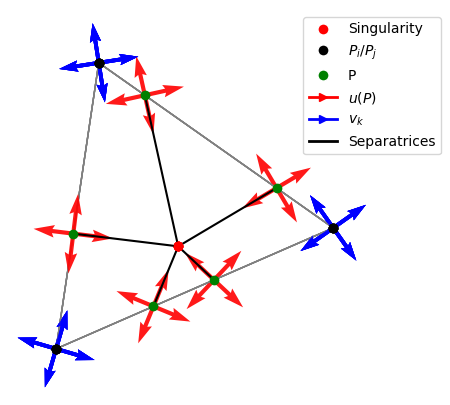

In [141]:
plot_one_separatrices(mesh,0)

In [22]:
def find_containing_face(point, mesh):
    
    nodes           = mesh.x[:,0:2]
    node_to_face_ID = mesh.nodes_faces_idsfontsize=12
    faces           = mesh.faces
    
    distances        = np.linalg.norm(nodes - point, axis=1)
    closest_node_idx = np.argmin(distances)
    possible_faces   = node_to_face_ID[closest_node_idx]
    
    for face_idx in possible_faces:
        face_vertices = faces[:,face_idx]
        triangle_vertices = nodes[face_vertices,0:2]
        if is_point_in_triangle(point, triangle_vertices):
            return face_idx

    return None
def is_point_inside_mesh(point, mesh):

    face_idx = find_containing_face(point, mesh)
    return face_idx is not None
def is_point_in_triangle(point, vertices):
    """
    Determines if a point is inside the triangle defined by the given vertices.

    Args:
        point (torch.Tensor): The point to check (shape: [2]).
        vertices (torch.Tensor): The vertices of the triangle (shape: [3, 2]).

    Returns:
        is_inside (bool): True if the point is inside the triangle, False otherwise.
    """
    # Compute vectors
    v0 = vertices[2] - vertices[0]
    v1 = vertices[1] - vertices[0]
    v2 = point - vertices[0]

    # Compute dot products
    dot00 = torch.dot(v0, v0)
    dot01 = torch.dot(v0, v1)
    dot02 = torch.dot(v0, v2)
    dot11 = torch.dot(v1, v1)
    dot12 = torch.dot(v1, v2)

    # Compute barycentric coordinates
    denom = dot00 * dot11 - dot01 * dot01
    if denom == 0:
        return False  # Degenerate triangle

    invDenom = 1 / denom
    u = (dot11 * dot02 - dot01 * dot12) * invDenom
    v = (dot00 * dot12 - dot01 * dot02) * invDenom

    # Check if point is inside the triangle
    return (u >= 0) and (v >= 0) and (u + v <= 1)

def runge_kutta_heun_integrate_streamline(start_point, start_direction, mesh,streamline, step_size=0.0025, max_steps=1000):

    # Initialize the streamline
#     streamline.append(start_point.numpy())
    current_point = start_point.clone().detach()
    current_direction = start_direction / torch.norm(start_direction)  # Ensure unit vector
    current_face_idx = find_containing_face(current_point, mesh)
    
    init_face_idx = current_face_idx
    

        
    mesh.face_streamline_labels[current_face_idx] = 1


    for step in range(max_steps):
       
        # Evaluate the vector field at the current point
        v_current,mesh = get_best_cross_vector(current_point, current_direction, mesh, current_face_idx)
        if v_current is None:
            print("Current point is outside the mesh.")
            break
        v_current = v_current / torch.norm(v_current)  # Ensure unit vector

        predictor_point   = current_point + step_size * v_current
        predicted_face_id = find_containing_face(predictor_point, mesh) 
        
        if predicted_face_id is None:
            break
            
        
        if mesh.singularities[predicted_face_id] != 0:
            if predicted_face_id != init_face_idx:# reached other singularity
                break
        if predicted_face_id != current_face_idx:
            mesh.face_streamline_labels[predicted_face_id] = 1
        
        # Evaluate the vector field at the predicted point
        v_predictor,mesh = get_best_cross_vector(predictor_point, v_current, mesh,predicted_face_id)
        if v_predictor is None:
#             print("Predictor point is outside the mesh.")
            break
        v_predictor = v_predictor / torch.norm(v_predictor)  # Ensure unit vector

        # Corrector step: Average the vector fields
        average_direction = (v_current + v_predictor) / 2.0
        average_direction = average_direction / torch.norm(average_direction)  # Normalize

        # Update the current point
        next_point = current_point + step_size * average_direction

        # Check if the next point is outside the mesh
        if not is_point_inside_mesh(next_point, mesh):
#             print("Next point is outside the mesh.")
            break
        new_face_id = find_containing_face(next_point, mesh) 
        
        
        if new_face_id is None:
                break
        
        if new_face_id != init_face_idx:
            if mesh.singularities[new_face_id] != 0:
                # reached other singularity
                break
        if  new_face_id != predicted_face_id:
            mesh.face_streamline_labels[new_face_id] = 1
                
        # Update current point and direction
        current_point = next_point
        current_direction = average_direction
        current_face_idx = new_face_id
        # Store the point
        streamline.append(current_point.numpy())

    return np.array(streamline)


In [23]:
def add_face_streamline_labels(mesh):
    num_faces = mesh.faces.size(1)
    face_streamline_labels = torch.zeros((num_faces))
    mesh.face_streamline_labels = face_streamline_labels
    return mesh

In [24]:
def get_streamlines(mesh):
    streamlines = []
    mesh = add_face_streamline_labels(mesh)
    
    for i in range(len(mesh.separatrices)):
        streamline           = []
        
        start_coords         = (mesh.separatrices[i]['coordinates']).to(torch.float)
        start_direction      = (mesh.separatrices[i]['vector']).to(torch.float)
        singularity_coords   = mesh.separatrices[i]['singularity_coords']
        
        streamline.append(singularity_coords.numpy())
        streamline.append(start_coords.numpy())
        streamline          = runge_kutta_heun_integrate_streamline(start_coords,start_direction,mesh,streamline)
        streamlines.append(streamline)
    mesh.streamlines = streamlines
    return mesh

In [25]:
def get_separatrices_from_c0_nodes(mesh):
    mask_c0_nodes = mesh.x[:, 2] == 0
    c0_nodes = mesh.x[mask_c0_nodes, 0:2]
    node_ids = torch.arange(mesh.x.size(0))
    c0_node_ids = node_ids[mask_c0_nodes]
    num_c0_nodes = c0_nodes.size(0)
    separatrices = mesh.separatrices
    tolerance = 1e-3
    angle_tolerance = 1e-2
    num_of_ts = 10000
    t = torch.arange(0, 1, 1 / num_of_ts)

    for i,node_id_tensor in enumerate(c0_node_ids):

        

        node_id       = node_id_tensor.item()
        neighbour_ids = get_neighbors(node_id)

        source_node   = mesh.x[node_id,0:2]

        for j in range(neighbour_ids.size(0)):

            neighbour_id   = neighbour_ids[j]
            neighbour_node = mesh.x[neighbour_id,0:2]

            edge_vec = neighbour_node - source_node
            ref_vec0 = mesh.u[node_id]
            ref_vec1 = mesh.u[neighbour_id]
            
            for i in range(num_of_ts):
                current_node = source_node + t[i] * edge_vec
               
                # Use get_best_cross_vector to interpolate the vector at the current_node
                previous_direction = current_node - source_node
                best_vector, _ = get_best_cross_vector(current_node, previous_direction, mesh, face_id)

                separatrix_vec = current_node - source_node
                separatrix_angle = torch.atan2(separatrix_vec[1], separatrix_vec[0]) % (2 * torch.pi)
                cross_vec_angle = torch.atan2(best_vector[1], best_vector[0]) % (2 * torch.pi)
                
                diff_angles = torch.abs(separatrix_angle - cross_vec_angle)

                if diff_angles < tolerance:
                    # Check if a separatrix with a similar angle already exists
                    if already_found_separatrix(separatrices, separatrix_angle, angle_tolerance):
                        update_if_better_separatrix(separatrices, separatrix_angle, current_node, best_vector, angle_tolerance, singularity_coords, face_id)
                    else:
                        separatrices.append({
                            'coordinates': current_node,
                            'angle': separatrix_angle,
                            'vector': best_vector,
                            'singularity_coords': singularity_coords,
                            'face_id': face_id
                        })

    mesh.separatrices = separatrices
        
    return mesh

In [26]:
def get_separatrices_from_c0_nodes(mesh):
    mask_c0_nodes = mesh.x[:, 2] == 0
    c0_nodes = mesh.x[mask_c0_nodes, 0:2]
    node_ids = torch.arange(mesh.x.size(0))
    c0_node_ids = node_ids[mask_c0_nodes]
    separatrices = mesh.separatrices
    tolerance = 1e-3
    angle_tolerance = 1e-2
    num_of_ts = 10000
    t = torch.linspace(0, 1, num_of_ts)
    step = 0.001
    for i, node_id_tensor in enumerate(c0_node_ids):
        node_id = node_id_tensor.item()
        
        source_node = mesh.x[node_id, 0:2]
        ref_vec = mesh.u[node_id]
        base_angle = torch.atan2(ref_vec[1], ref_vec[0])
        for k in range(4):
            angle = base_angle/4 +k*torch.pi/2
            vec = torch.tensor([torch.cos(angle), torch.sin(angle)])
            
            next_node = source_node+step*vec
            next_node = next_node.to(torch.float)

            # next_node
            if is_point_inside_mesh(next_node, mesh):
                
                new_face_id = find_containing_face(next_node, mesh)       
        
                if new_face_id is None:
                        break
                separatrices.append({
                            'coordinates': next_node,
                            'angle': angle,
                            'vector': vec,
                            'singularity_coords': source_node,
                            'face_id': new_face_id  # No face since it's a C0 boundary
                        })

    mesh.separatrices = separatrices
    return mesh


In [27]:
def get_neighbors(node_id):
    
    faces                  = mesh.faces[:,mesh.nodes_faces_ids[node_id]]
    self_and_neighbour_ids = torch.unique(torch.cat((faces[0,:],faces[1,:],faces[2,:])))
    mask                   = self_and_neighbour_ids != node_id
    neighbours             = self_and_neighbour_ids[mask]
    
    return neighbours

In [28]:
import matplotlib.pyplot as plt

def plot_mesh(mesh):

    nodes = mesh.x[:, 0:2]  
    edges = mesh.edge_index

    plt.figure(figsize=(8, 8))
    
    # Plot the mesh by drawing the triangles
    for face in mesh.faces.T:  # Transposing to iterate through each face
        triangle = nodes[face, :]
        plt.fill(triangle[:, 0], triangle[:, 1], edgecolor='gray', fill=False, linewidth=0.5)
    for e in range(edges.size(1)):
        if mesh.edge_attr[e]==1:
            n1 = mesh.x[edges[0,e],:]
            n2 = mesh.x[edges[1,e],:]
            plt.plot([n1[0],n2[0]],[n1[1],n2[1]],'r')

    # Set plot details
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.gca().set_aspect('equal', adjustable='box')
#     plt.legend()
    plt.grid(True)
    
    # Show the plot
    plt.show()


In [29]:
import matplotlib.pyplot as plt

def plot_streamlines(mesh):
    streamlines = mesh.streamlines
    nodes = mesh.x[:, 0:2]  # Assuming we are using 2D coordinates (x, y)
    edges = mesh.edge_index
    # Create a figure for plotting
    plt.figure(figsize=(8, 8))
    
    # Plot the mesh by drawing the triangles
    for face in mesh.faces.T:  # Transposing to iterate through each face
        triangle = nodes[face, :]
        plt.fill(triangle[:, 0], triangle[:, 1], edgecolor='gray', fill=False, linewidth=0.5)
    for e in range(edges.size(1)):
        if mesh.edge_attr[e]==1:
            n1 = mesh.x[edges[0,e],:]
            n2 = mesh.x[edges[1,e],:]
            plt.plot([n1[0],n2[0]],[n1[1],n2[1]],'r')
    # Plot each streamline
    for streamline in streamlines:
        streamline = np.array(streamline)  # Convert to numpy array for easier plotting
        plt.plot(streamline[:, 0], streamline[:, 1],'r')
    
    # Set plot details
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Streamlines over Mesh')
    plt.gca().set_aspect('equal', adjustable='box')
#     plt.legend()
    plt.grid(True)
    
    # Show the plot
    plt.show()


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (BSpline)
Info    : [ 80%] Meshing curve 6 (BSpline)
Info    : [ 90%] Meshing curve 7 (BSpline)
Info    : Done meshing 1D (Wall 0.00761347s, CPU 0.008236s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0326275s, CPU 0.032794s)
Info    : 510 nodes 819 elements
Konvergenz erreicht nach 21 Iterationen.
number of singularities is correct


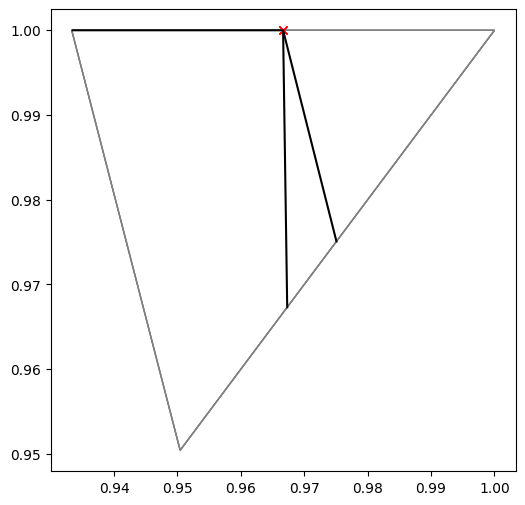

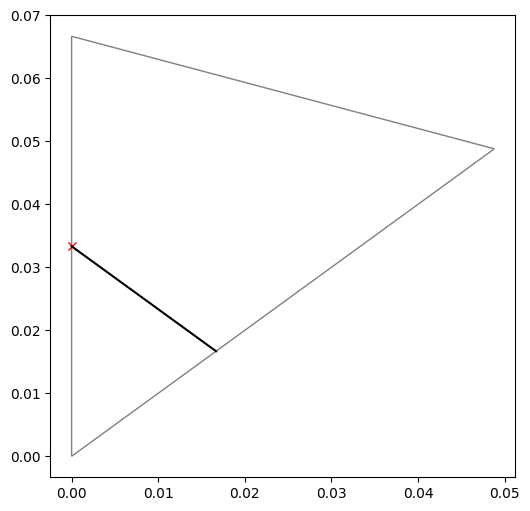

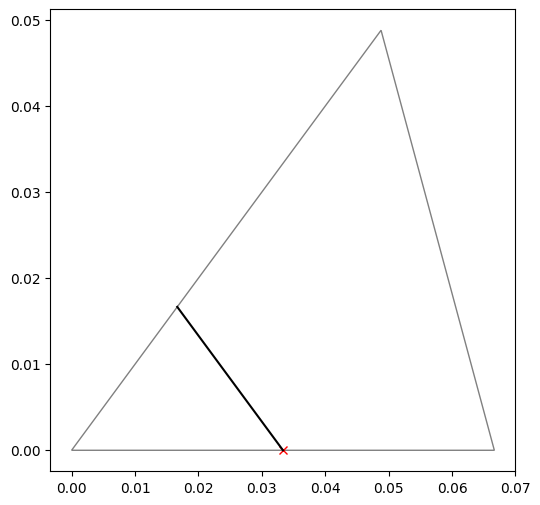

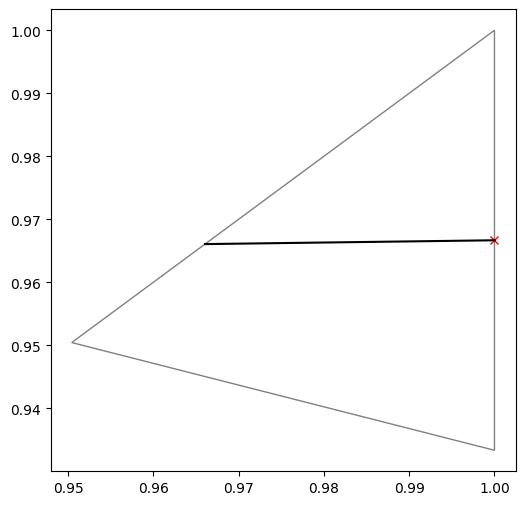

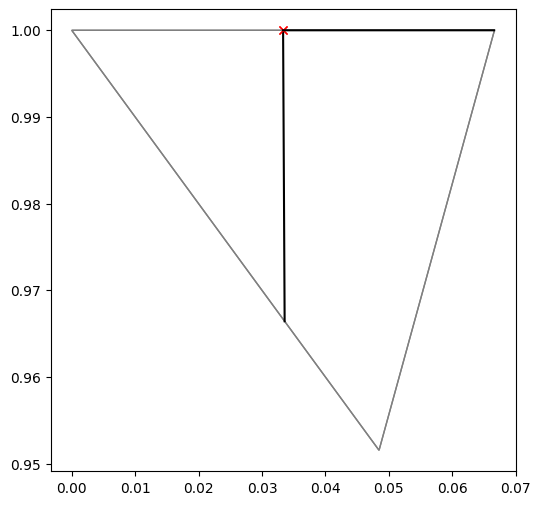

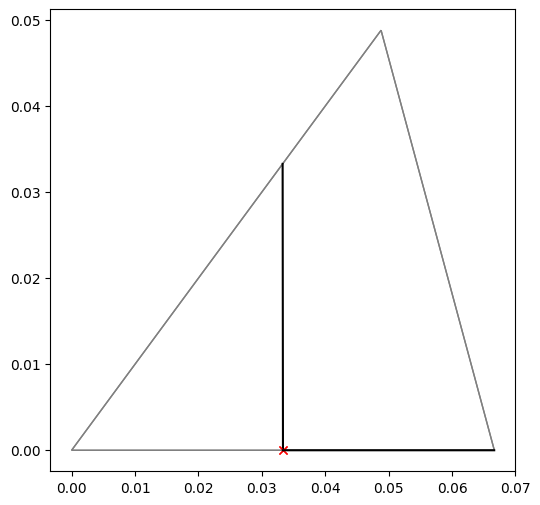

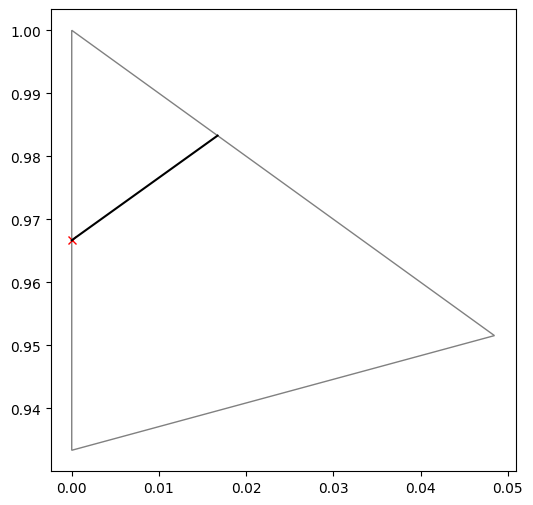

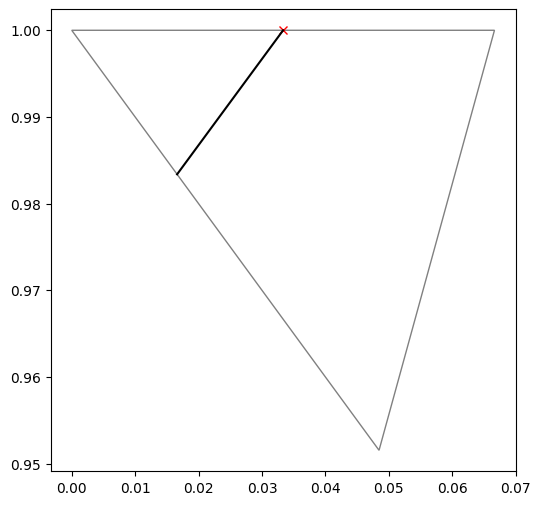

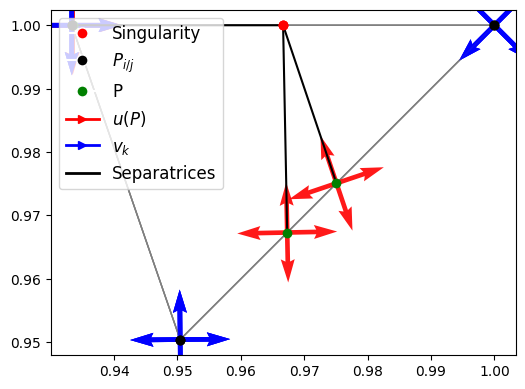

In [48]:
airfoil = NACA_airfoil()
mesh_gen = MeshGenerator(airfoil, quadMesh=False, lc=0.07)
mesh = mesh_gen.mesh
frameField = FrameField(mesh)
mesh = frameField.mesh
mesh = detect_singularities(mesh)
mesh = get_separatrices_from_singularity(mesh)
plot_separatrices(mesh)
plot_one_separatrices(mesh,0)

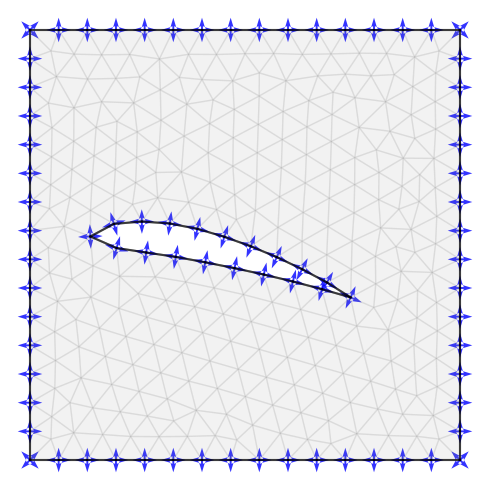

In [32]:
plot_cross_field(mesh)

In [45]:
# plot_frame_field(mesh,init=True,scale=7,output_file="frame_field_init.png")

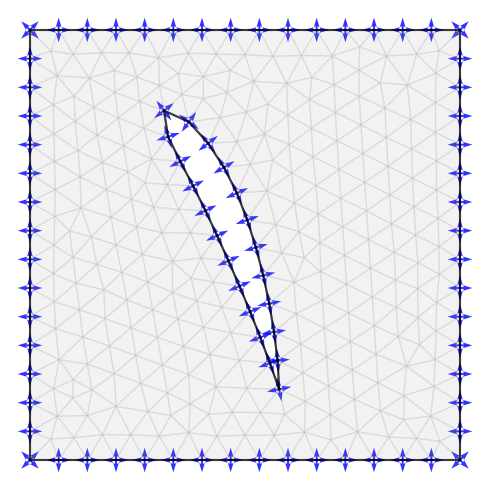

In [34]:
plot_cross_field(mesh,init=True,output_file="cross_field_init.png")

In [46]:
import matplotlib.pyplot as plt
import numpy as np

def plot_fake_streamlines(mesh, exclude_indices=None):
    """
    Plots streamlines over the mesh.
    
    Args:
        mesh: The mesh containing nodes, faces, edges, and streamlines.
        exclude_indices (list, optional): A list of streamline indices that should NOT be plotted.
    """
    streamlines = mesh.streamlines
    nodes = mesh.x[:, 0:2]  # Assuming we are using 2D coordinates (x, y)
    edges = mesh.edge_index

    # Convert exclude_indices to a set for fast lookup
    exclude_indices = set(exclude_indices) if exclude_indices is not None else set()

    # Create a figure for plotting
    plt.figure(figsize=(5, 5))
    
    # Plot the mesh by drawing the triangles
    for face in mesh.faces.T:  # Transposing to iterate through each face
        triangle = nodes[face, :]
        plt.fill(triangle[:, 0], triangle[:, 1], edgecolor='gray', fill=False, linewidth=0.5,alpha=0.8)
    
    # Plot edges where `mesh.edge_attr[e] == 1`
    for e in range(edges.size(1)):
        if mesh.edge_attr[e] == 1:
            n1 = mesh.x[edges[0, e], :]
            n2 = mesh.x[edges[1, e], :]
            plt.plot([n1[0], n2[0]], [n1[1], n2[1]], 'r')
    
    # Plot each streamline except those in exclude_indices
    for i, streamline in enumerate(streamlines):
        if i in exclude_indices:
            continue  # Skip plotting this streamline
        streamline = np.array(streamline)  # Convert to numpy array for easier plotting
        plt.plot(streamline[:, 0], streamline[:, 1], 'r')

    # Set plot details
#     plt.xlabel('X')
#     plt.ylabel('Y')
#     plt.title('Streamlines over Mesh')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)
    plt.axis('off')
    plt.tight_layout()
    output_file="streamlines.png"
    plt.savefig(output_file, dpi=300)
    # Show the plot
    plt.show()


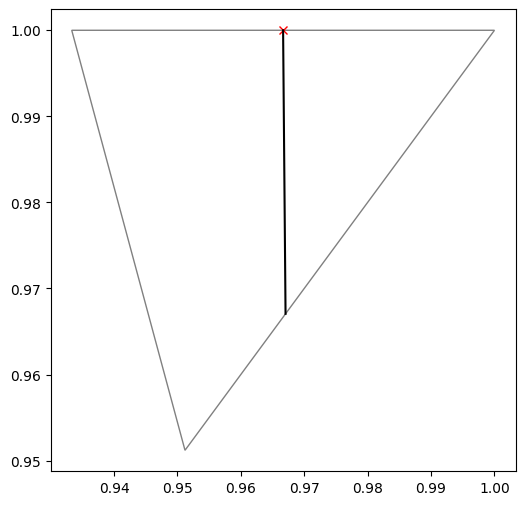

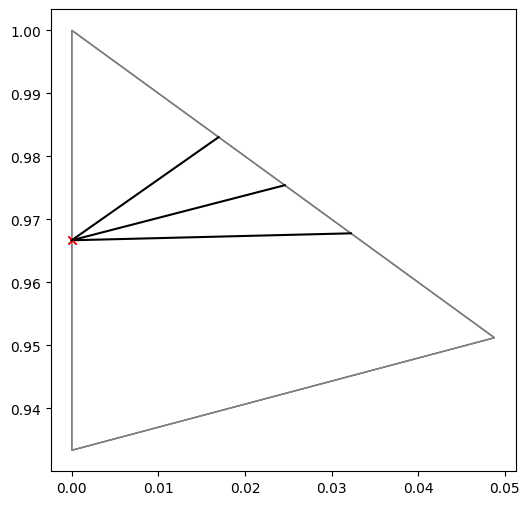

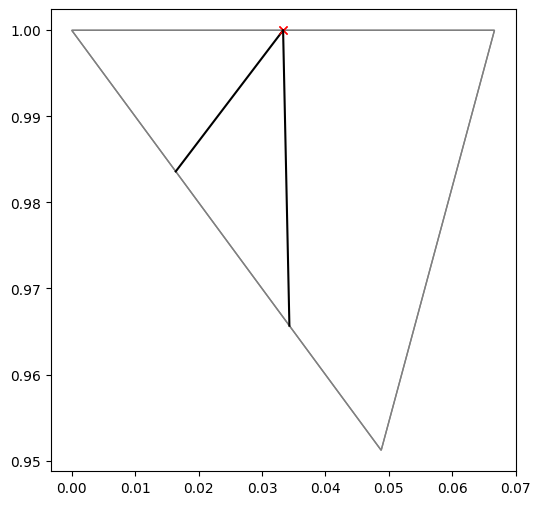

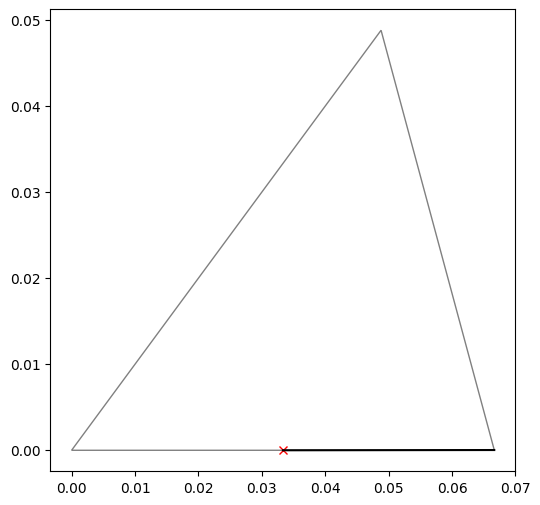

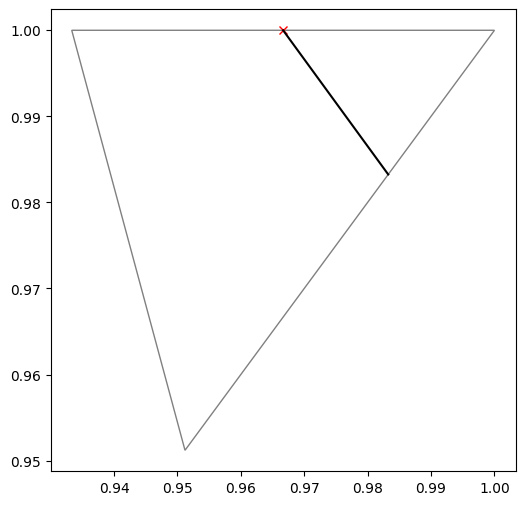

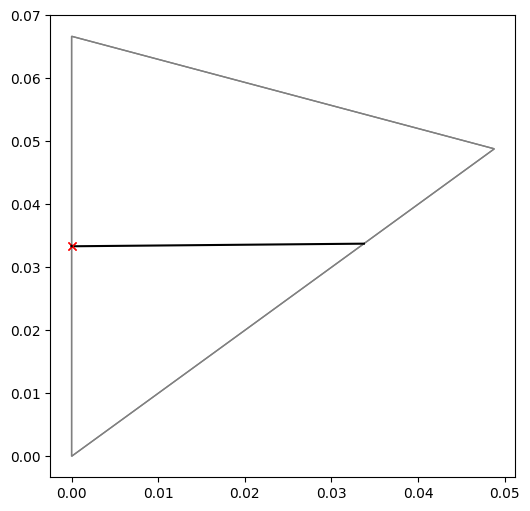

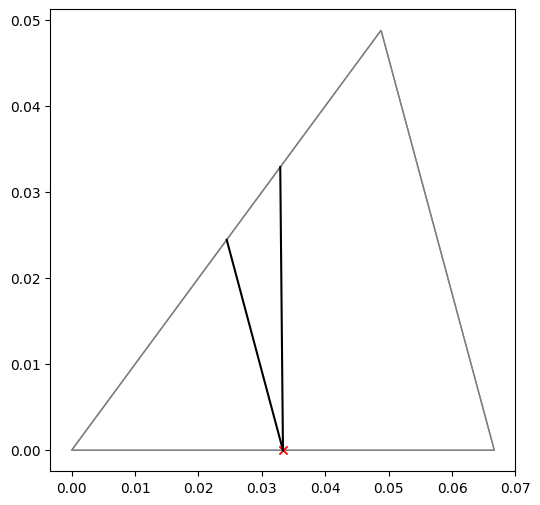

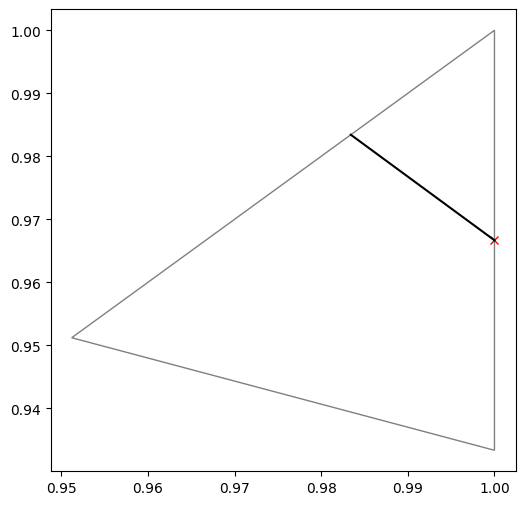

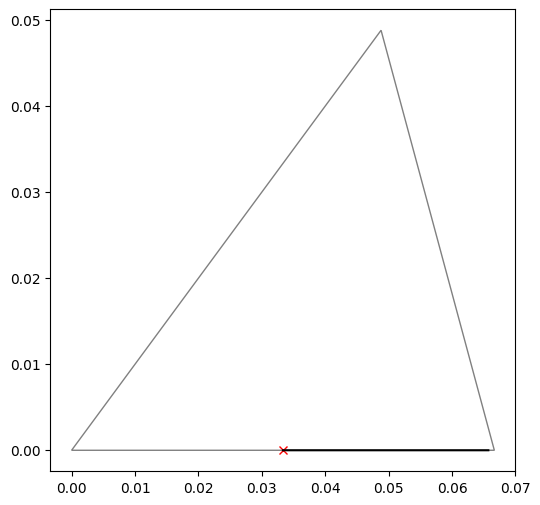

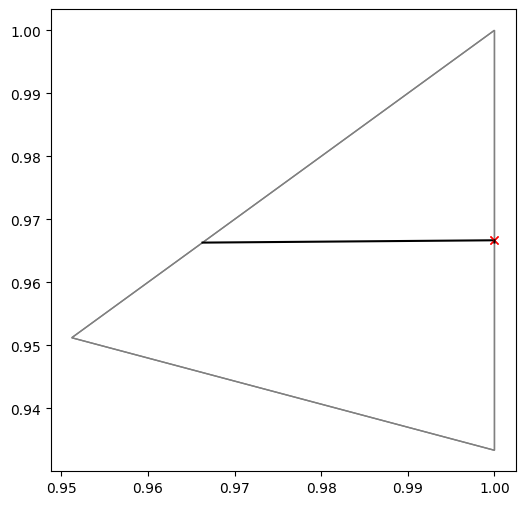

In [47]:
plot_separatrices(mesh)

In [54]:
mesh = get_separatrices_from_singularity(mesh)

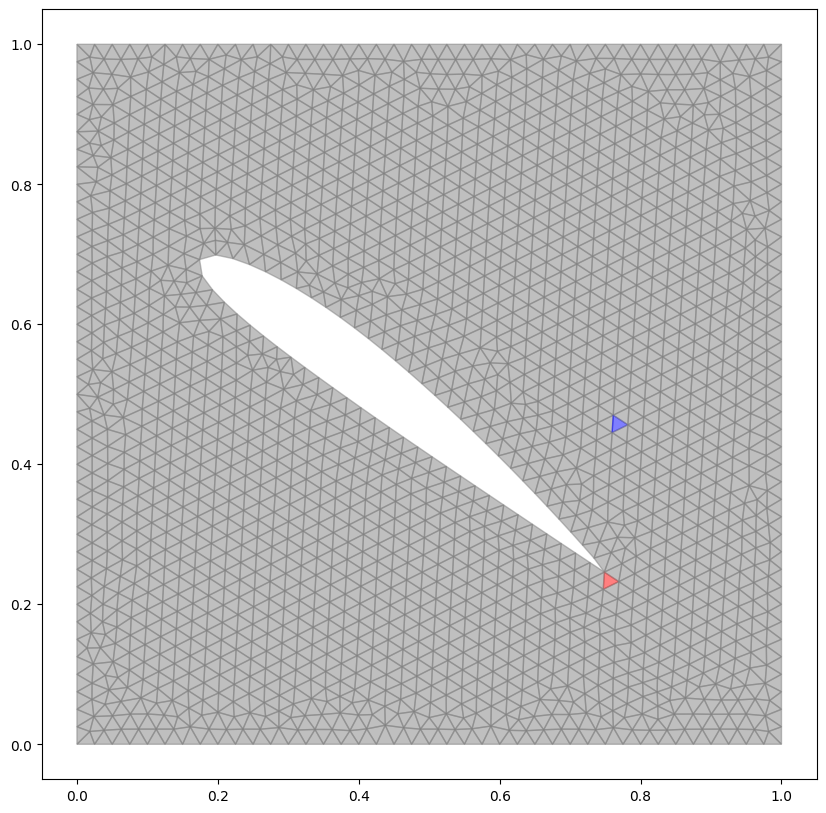

In [131]:
plot_singularities(mesh)